# Analyse, Segmentation et Prédiction du Churn Client

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

## 1. Analyse et préparation des données

In [2]:
data = pd.read_csv("../data/wa-fn-usec-telco-customer-churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7043, 21)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data["SeniorCitizen"] = data["SeniorCitizen"].astype(bool)
# map(lambda x: np.nan if not x.strip() else float(x.strip()))

In [26]:
cols_to_update = [
  "Partner",
  "Dependents",
  "PhoneService",
  "MultipleLines",
  "OnlineSecurity",
  "OnlineBackup",
  "DeviceProtection",
  "TechSupport",
  "StreamingTV",
  "StreamingMovies",
  "PaperlessBilling",
  "Churn"
]
try:
  for cl in cols_to_update:
    data[cl] = data[cl].map(
      lambda x : True if str.capitalize(x)in['Yes', 'Y'] else False
    )
except ValueError as ve:
  print(ve)
except Exception as e:
  print(e)
finally:
  display(data.dtypes)

customerID              str
gender                  str
SeniorCitizen          bool
Partner                bool
Dependents             bool
tenure                int64
PhoneService           bool
MultipleLines          bool
InternetService         str
OnlineSecurity         bool
OnlineBackup           bool
DeviceProtection       bool
TechSupport            bool
StreamingTV            bool
StreamingMovies        bool
Contract                str
PaperlessBilling       bool
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                  bool
dtype: object

In [28]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [29]:
data.describe(include="str")

,customerID,gender,InternetService,Contract,PaymentMethod
count,7043,7043,7043,7043,7043
unique,7043,2,3,3,4
top,7590-VHVEG,Male,Fiber optic,Month-to-month,Electronic check
freq,1,3555,3096,3875,2365


In [9]:
display(data["InternetService"].unique())
display(data["Contract"].unique())
display(data["PaymentMethod"].unique())

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [33]:
data.describe(include="bool")

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,2,2,2,2,2,2,2,2
top,False,False,False,True,False,False,False,False,False,False,False,True,False
freq,5901,3641,4933,6361,4072,5024,4614,4621,4999,4336,4311,4171,5174


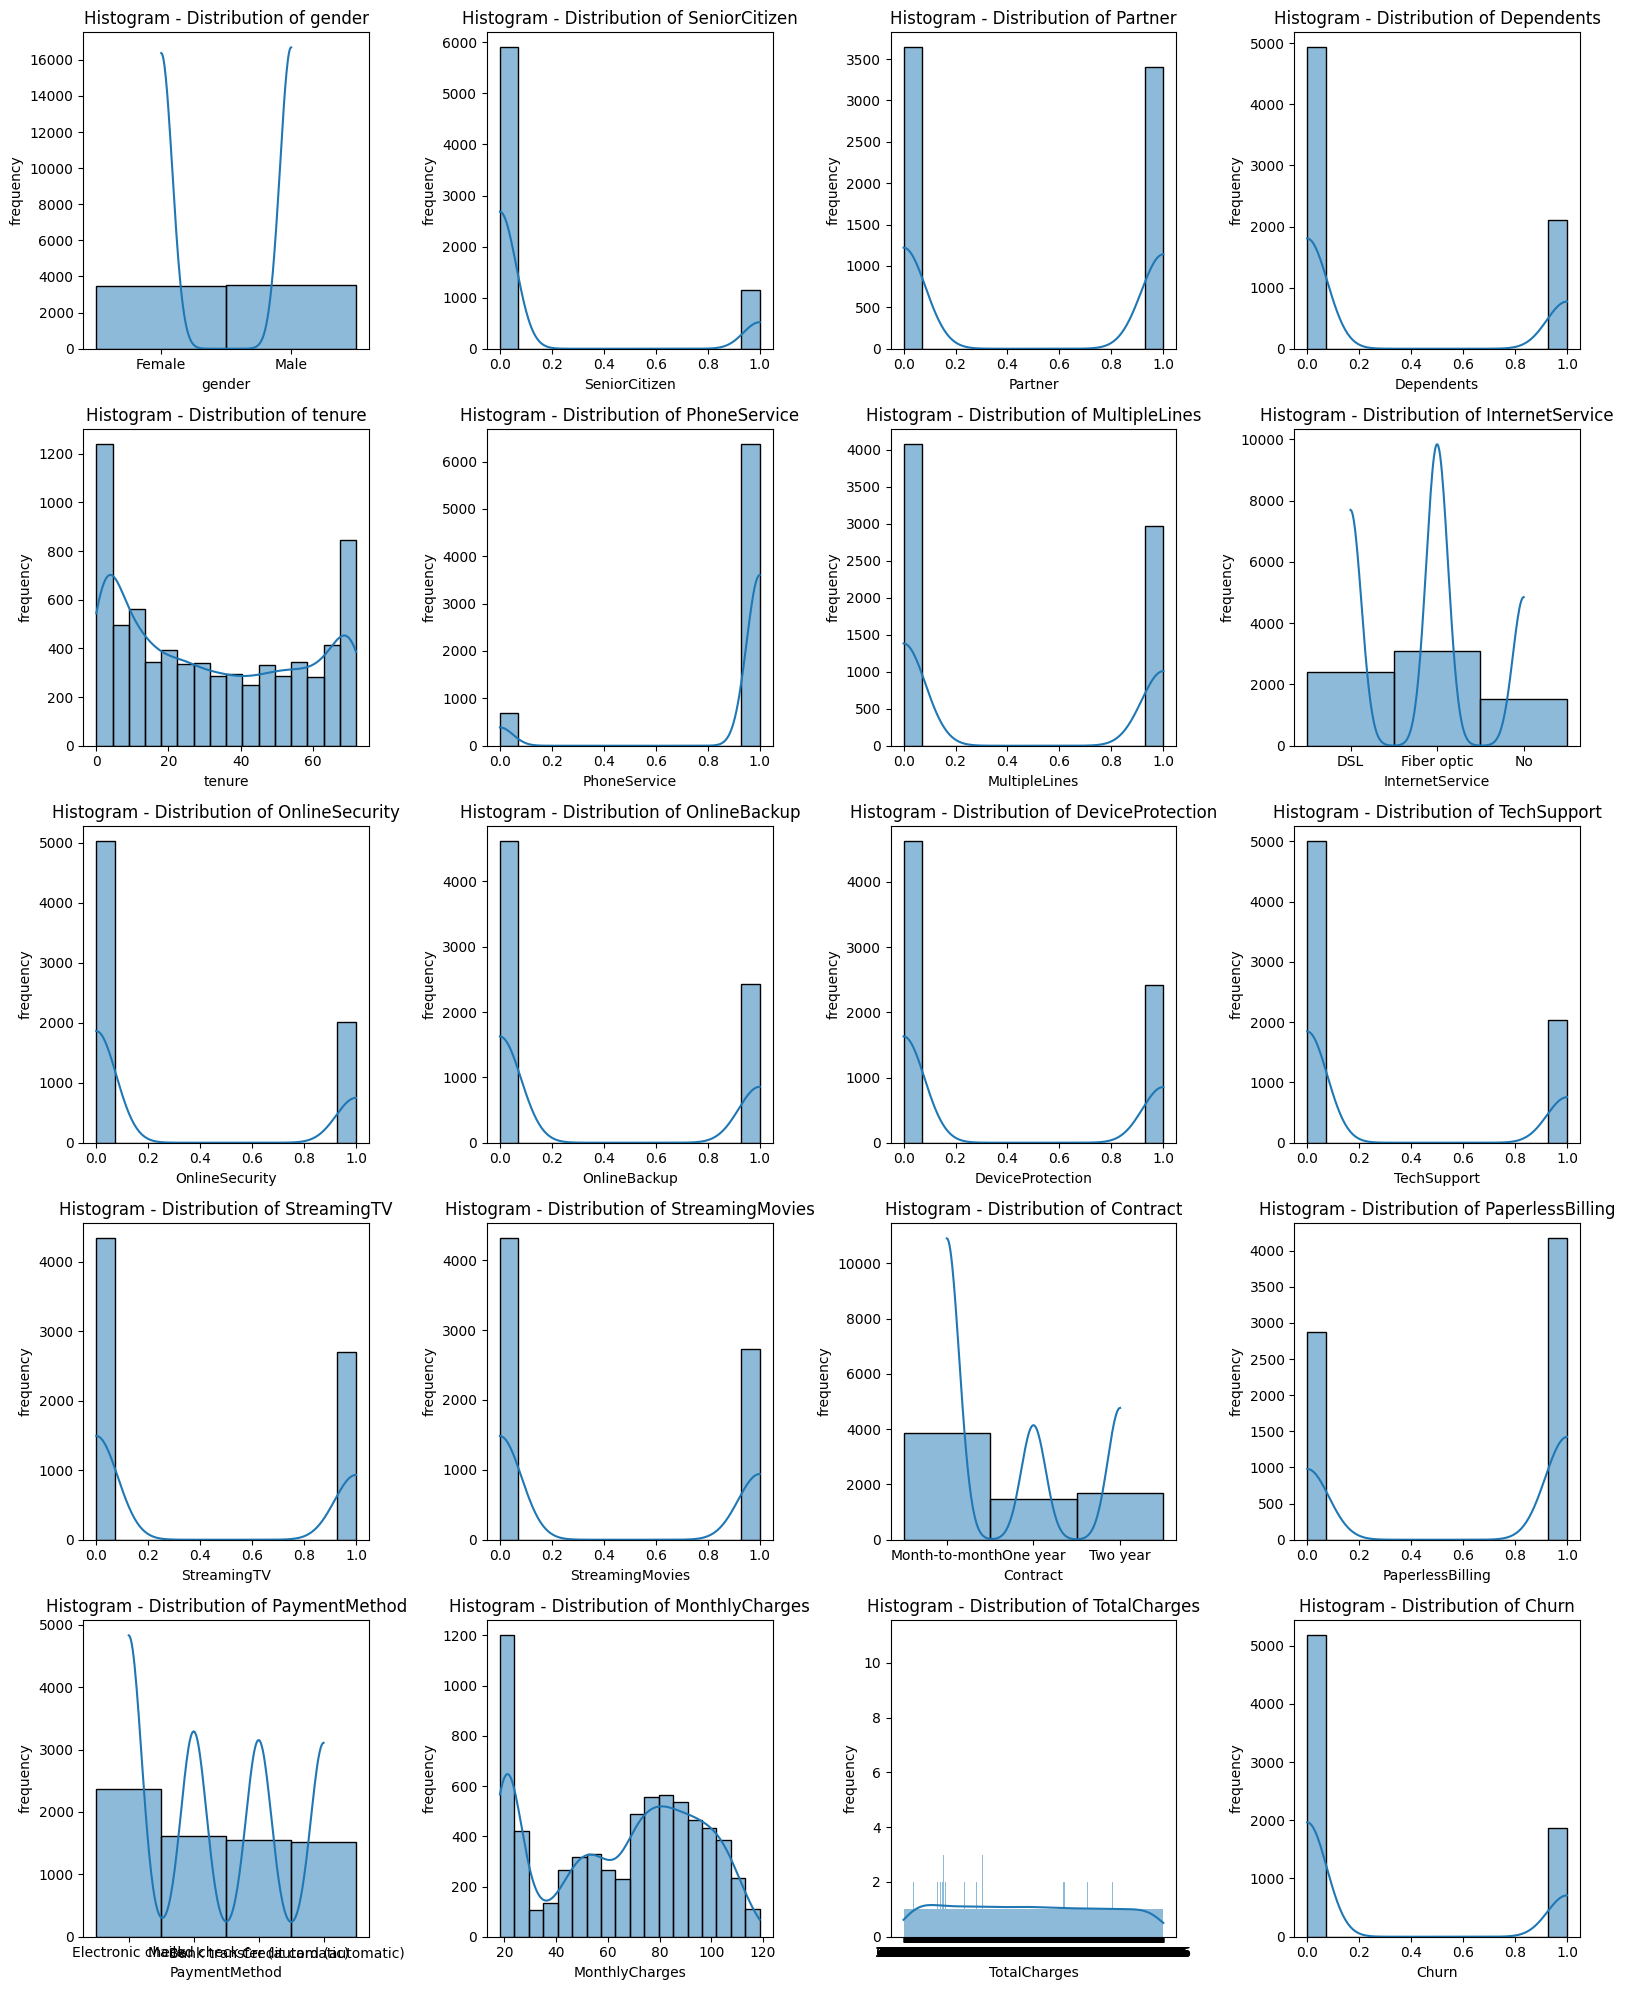

In [36]:
fig, axs = plt.subplots(5, 4, figsize=(16, 20))
plot_data = data.drop("customerID", axis=1)
for i, axe in enumerate(axs.flat):
    sb.histplot(data=plot_data.iloc[:,i], kde=True, ax=axe)
    axe.set_title(f"Histogram - Distribution of {plot_data.iloc[:,i].name}")
    axe.set_xlabel(plot_data.iloc[:,i].name)
    axe.set_ylabel("frequency")

plt.tight_layout()
plt.show()

In [6]:
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
data[data["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,False,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,False,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,False,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
data.fillna({'TotalCharges':0}, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,False,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,False,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,False,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,False,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,False,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,False,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,False,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,True,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [26]:
data[data["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [27]:
data.iloc[488, :]

customerID                         4472-LVYGI
gender                                 Female
SeniorCitizen                           False
Partner                                  True
Dependents                               True
tenure                                      0
PhoneService                            False
MultipleLines                           False
InternetService                           DSL
OnlineSecurity                           True
OnlineBackup                            False
DeviceProtection                         True
TechSupport                              True
StreamingTV                              True
StreamingMovies                         False
Contract                             Two year
PaperlessBilling                         True
PaymentMethod       Bank transfer (automatic)
MonthlyCharges                          52.55
TotalCharges                              0.0
Churn                                   False
Name: 488, dtype: object

In [37]:
data[data.duplicated()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [9]:
X = data.iloc[:, :-1].drop("customerID", axis=1)
y = data.Churn
display("features shape:", X.shape)
display("Target shape:", y.shape)

'features shape:'

(7043, 19)

'Target shape:'

(7043,)

In [13]:
X.to_csv("../data/cleaned_data.csv", index=False)

In [39]:
numerical_features = X.select_dtypes(include="number").columns
numerical_features

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

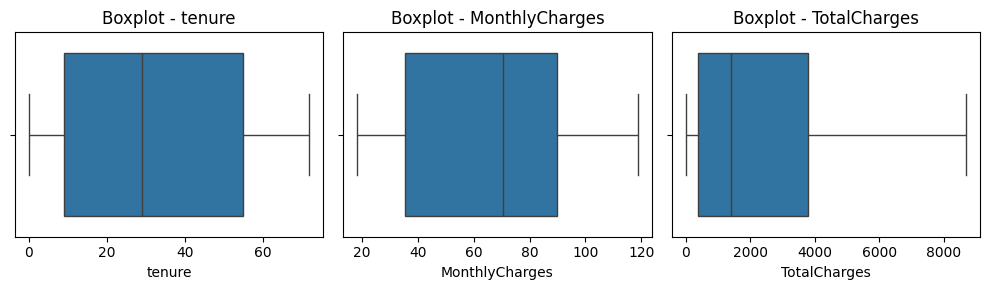

In [59]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
i=0

for feature in numerical_features:
  sb.boxplot(data[feature], ax=axs[i], orient="h")
  axs[i].set_title(f"Boxplot - {feature}")
  i+=1

plt.tight_layout()
plt.show()


In [41]:
categorical_features = X.select_dtypes(include="str").columns
categorical_features

Index(['gender', 'InternetService', 'Contract', 'PaymentMethod'], dtype='str')

In [42]:
data_copy = X.copy()

for feature in categorical_features:
  data_copy[feature] = data_copy[feature].astype('category').cat.codes

data_copy.corrwith(data["Churn"].astype('category').cat.codes)

gender             -0.008612
SeniorCitizen       0.150889
Partner            -0.150448
Dependents         -0.164221
tenure             -0.352229
PhoneService        0.011942
MultipleLines       0.040102
InternetService    -0.047291
OnlineSecurity     -0.171226
OnlineBackup       -0.082255
DeviceProtection   -0.066160
TechSupport        -0.164674
StreamingTV         0.063228
StreamingMovies     0.061382
Contract           -0.396713
PaperlessBilling    0.191825
PaymentMethod       0.107062
MonthlyCharges      0.193356
TotalCharges       -0.198324
dtype: float64

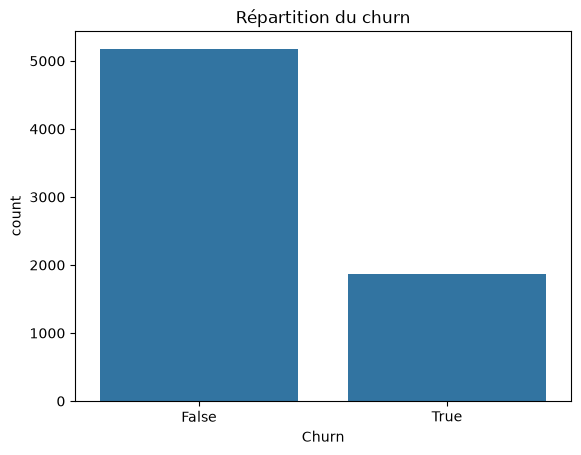

In [34]:
sb.countplot(data=data, x="Churn")
plt.title("Répartition du churn")
plt.show()

**Des classes deséquilibrés** : environ 76% no et 24% yes

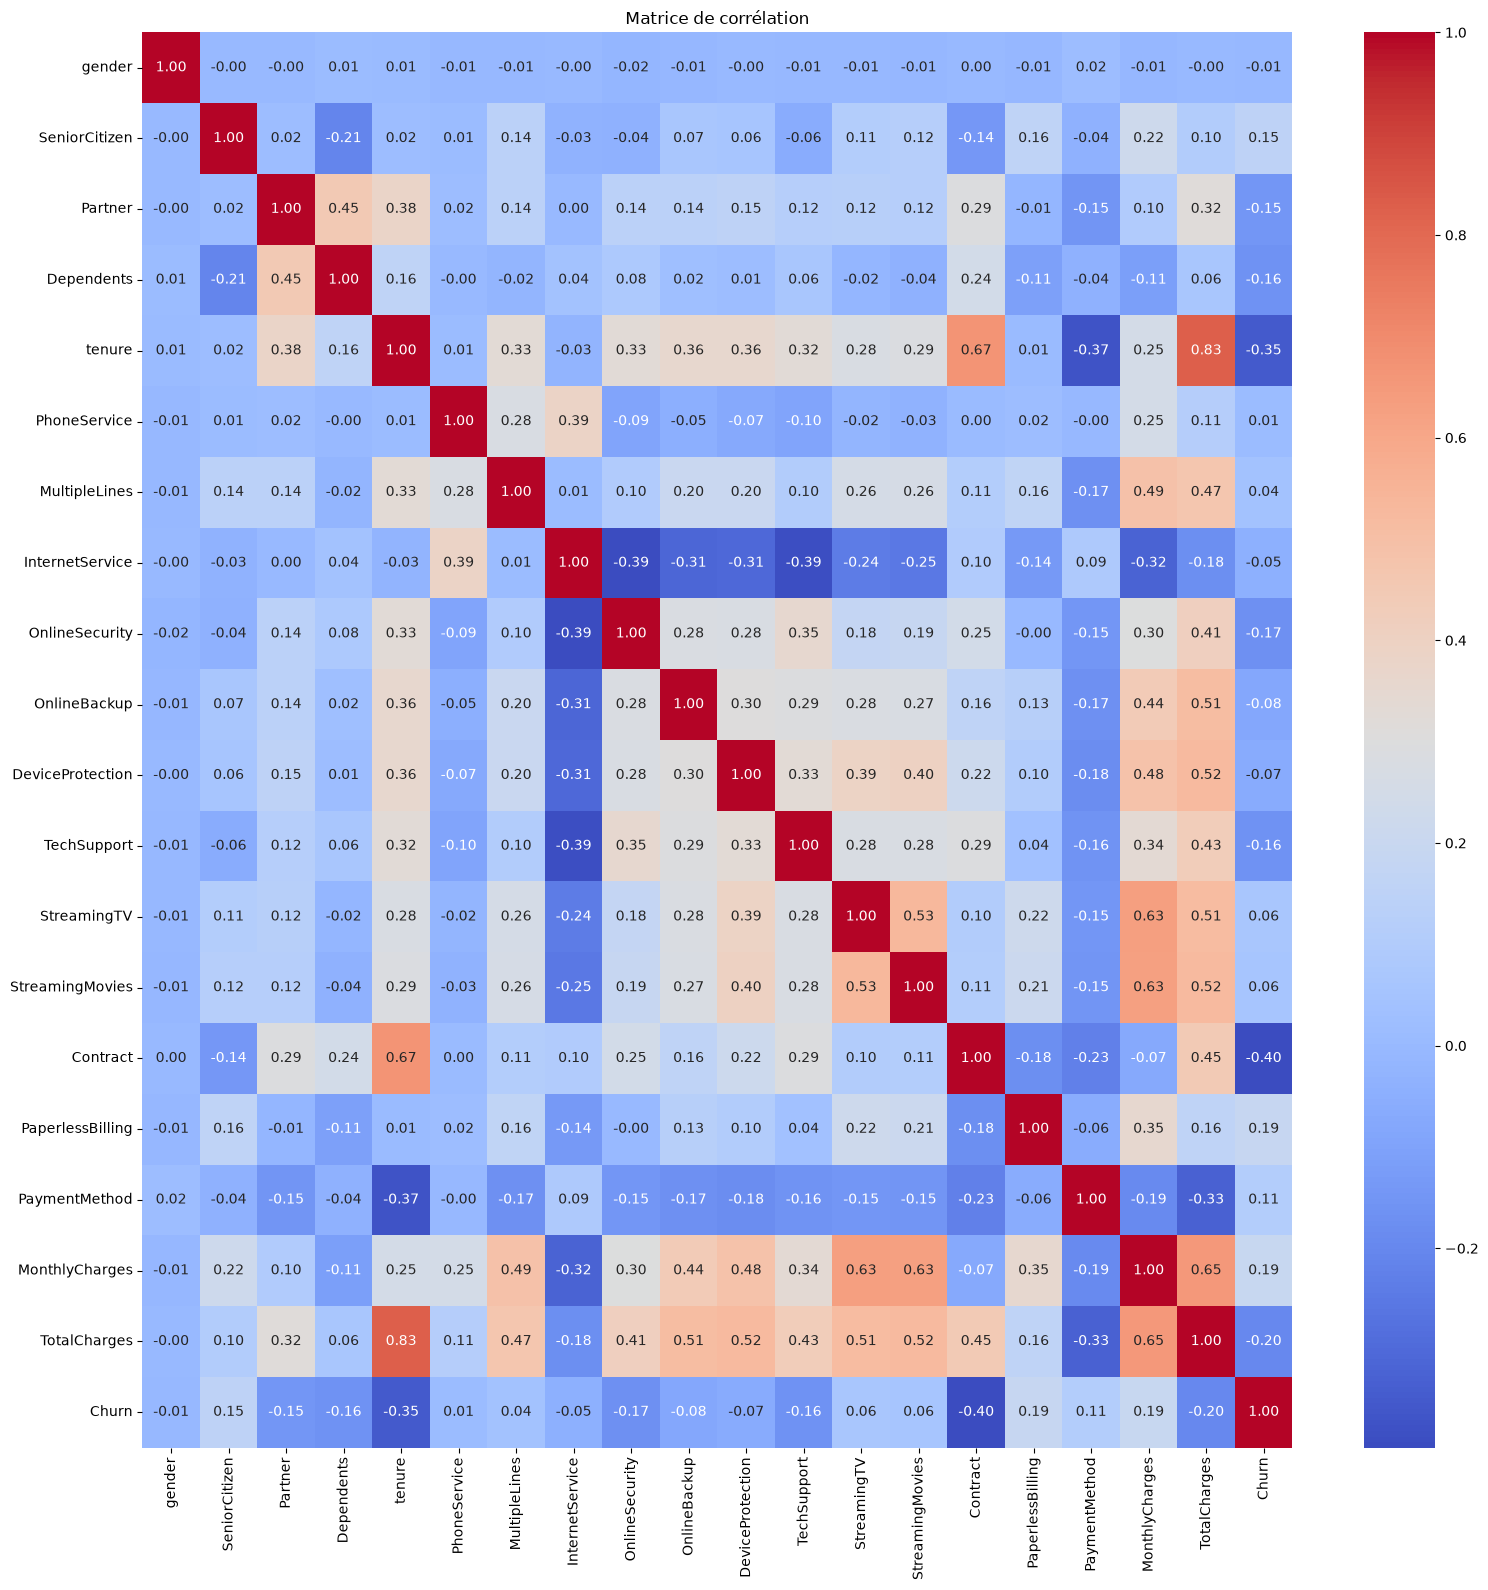

In [43]:
fig = plt.figure(figsize=(16,16))
corr_data = data_copy.copy()
corr_data['Churn'] = data["Churn"].astype('category').cat.codes
sb.heatmap(
    corr_data.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [44]:
categorical_features = categorical_features.drop("Contract")

In [45]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

categorical_encoder.fit(X[categorical_features])
categorical_features_encoded = pd.DataFrame(
    categorical_encoder.transform(X[categorical_features]),
    columns=categorical_encoder.get_feature_names_out(categorical_features),
    index=X.index
)
categorical_features_encoded


,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7039,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7040,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7041,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [46]:
categorical_features_encoded.drop("gender_Male", axis=1, inplace=True)

In [47]:
boolean_features = X.select_dtypes(include="bool").columns
boolean_features

Index(['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'],
      dtype='str')

In [48]:
preprocessed_data = categorical_features_encoded

In [49]:
bool_encoder = LabelEncoder()

for feature in boolean_features:
  preprocessed_data[feature] = bool_encoder.fit_transform(X[feature])

preprocessed_data["Contract"] = bool_encoder.fit_transform(X["Contract"])
preprocessed_data["Churn"] = bool_encoder.fit_transform(y)

In [50]:
preprocessed_data

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,Churn
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,1,0,1,0,0,0,0,1,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,1,1,0,0,0,0,1,0,1
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,0,1,0,1,1,0,0,0,1,0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,1,1,0,1,1,1,1,1,1,0
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,0,1,1,0,1,1,1,1,0
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,1,0,0,0,0,0,1,0,0
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,1,0,0,0,0,0,0,1,0,1


In [51]:
numerical_scaler = MinMaxScaler()

preprocessed_data[numerical_features] = numerical_scaler.fit_transform(X[numerical_features])

preprocessed_data


,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Contract,Churn,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,1,0,0,0,0,1,0,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,...,1,1,0,0,0,1,0,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,...,0,0,0,0,1,0,1,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,...,1,1,1,1,1,1,0,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1,...,1,0,1,1,1,1,0,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,...,0,0,0,0,1,0,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,1,0,1,0.055556,0.558706,0.035303


In [52]:
preprocessed_data.to_csv("../data/preprocessed_data.csv", index=False)